In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyg_dataset import NetlistDataset

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [2]:
dataset = NetlistDataset(data_dir="../data/superblue", load_pd = True, load_pe = True, pl = True, processed = True, load_indices=None)

  0%|          | 0/12 [00:00<?, ?it/s]c:\Users\rebal\chip-design\src\pyg_dataset.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(data_load_fp)
100%|██

In [3]:
node_features = []
node_demand = []
node_congestion = []
for i in [0, 1, 2, 3, 6, 7, 8, 9, 10, 11]:
    node_features.append(dataset[i].node_features.cpu().numpy())
    node_demand.append(dataset[i].node_demand.cpu().numpy())
    node_congestion.append(dataset[i].node_congestion.cpu().numpy())

train_features = np.concatenate(node_features)
train_demand = np.concatenate(node_demand)
train_congestion = np.concatenate(node_congestion)

test_features = dataset[5].node_features.cpu().numpy()
test_demand = dataset[5].node_demand.cpu().numpy()
test_congestion = dataset[5].node_congestion.cpu().numpy()

# idx = np.random.choice(a=[True, False], p=[0.2, 0.8], size=train_features.shape[0])
# train_features = train_features[idx]
# train_congestion = train_congestion[idx]

In [7]:
clf = QuadraticDiscriminantAnalysis()
clf.fit(train_features, train_congestion)

QuadraticDiscriminantAnalysis()

In [10]:
confusion_matrix(clf.predict(test_features), test_congestion)

array([[  5897,  19110],
       [176002, 294225]], dtype=int64)

In [15]:
lda = LinearDiscriminantAnalysis()
X_train = lda.fit_transform(train_features, train_congestion)

In [16]:
X_train

array([[-0.31156824],
       [-0.79683411],
       [-0.77737238],
       ...,
       [-0.48513762],
       [-0.48722525],
       [-0.49846772]])

In [ ]:
pca = PCA()
pca.fit(train_features[:, 1:])

PCA(n_components=44)

In [41]:
pca.explained_variance_ratio_

array([7.53571627e-01, 1.23642121e-01, 3.67270046e-02, 2.71765924e-02,
       1.63806883e-02, 1.15767791e-02, 8.69113343e-03, 8.46462586e-03,
       4.41474098e-03, 2.09763740e-03, 1.69892162e-03, 1.50037814e-03,
       1.08501288e-03, 9.56136716e-04, 4.30548085e-04, 4.03056093e-04,
       2.88521763e-04, 1.98262745e-04, 1.77308406e-04, 1.26492252e-04,
       9.56246674e-05, 8.48437410e-05, 7.02268455e-05, 5.43113932e-05,
       3.76787079e-05, 2.49513893e-05, 9.03213391e-06, 7.02668309e-06,
       5.58645921e-06, 2.25493791e-06, 8.54402227e-07, 2.03962298e-08,
       2.61573128e-11, 1.09723014e-11, 6.10567280e-12, 6.10525889e-12,
       6.10389313e-12, 6.09860590e-12, 6.09710683e-12, 6.09238780e-12,
       6.09054641e-12, 6.08418858e-12, 6.05655553e-12, 5.48109112e-12])

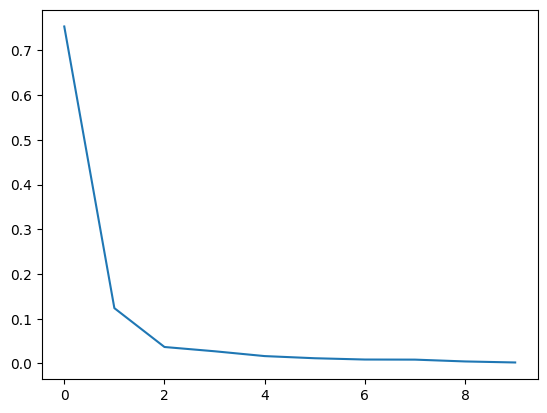

In [42]:
plt.plot(pca.explained_variance_ratio_[:10])

In [44]:
pca.components_[1]

array([ 2.4304538e-07,  2.9802322e-08, -1.2494624e-05, -6.0200691e-04,
        5.9604645e-08,  7.4505806e-09, -1.2805685e-08,  7.1668182e-09,
        1.2960754e-08, -1.8098660e-09,  1.0005126e-09,  7.7874001e-09,
       -3.8531280e-09,  6.3878511e-09,  2.9231608e-04,  5.7201833e-04,
        3.1413883e-04,  5.1690498e-04,  9.7954646e-04,  2.7778512e-04,
        1.5199895e-04,  2.3809960e-04,  3.0162715e-05, -2.0007373e-01,
       -1.9774142e-01, -3.3747111e-02, -3.7291873e-01, -3.2948264e-01,
       -4.2293940e-02,  4.7662370e-02, -4.1796394e-02, -7.4260067e-03,
       -3.3220649e-04, -7.6481505e-05,  8.2306877e-05,  4.9464451e-04,
        1.0493351e-03,  1.5925228e-03, -1.7888622e-02, -6.7825511e-02,
       -2.2629602e-01, -1.8647769e-01,  9.2641965e-02,  7.5282633e-01],
      dtype=float32)

In [38]:
pd.value_counts(train_features[:, 0])

7.0        960513
195.0      607409
53.0       592006
353.0      386892
354.0      386773
            ...  
29169.0         1
29168.0         1
29167.0         1
29166.0         1
27632.0         1
Name: count, Length: 6095, dtype: int64

In [45]:
counts = {}
for i in range(len(train_features)):
    if train_congestion[i] == 0:
        counts[(train_features[i][0], 0)] = counts.get((train_features[i][0], 0), 0) + 1
    else:
        counts[(train_features[i][0], 1)] = counts.get((train_features[i][0], 1), 0) + 1

In [46]:
counts

{(132.0, 1): 40137,
 (359.0, 0): 7844,
 (176.0, 1): 103127,
 (224.0, 1): 103127,
 (360.0, 1): 103263,
 (33.0, 1): 11078,
 (346.0, 1): 21900,
 (76.0, 1): 103185,
 (237.0, 1): 103306,
 (183.0, 1): 103501,
 (275.0, 1): 147969,
 (64.0, 1): 213488,
 (348.0, 0): 36168,
 (299.0, 1): 4046,
 (187.0, 1): 214230,
 (389.0, 1): 103109,
 (152.0, 1): 9949,
 (217.0, 1): 39930,
 (27.0, 1): 103401,
 (53.0, 1): 358920,
 (291.0, 1): 24993,
 (200.0, 1): 147935,
 (389.0, 0): 53391,
 (187.0, 0): 125872,
 (348.0, 1): 25140,
 (374.0, 1): 24922,
 (22.0, 1): 81258,
 (132.0, 0): 23235,
 (189.0, 1): 80927,
 (20.0, 1): 81047,
 (176.0, 0): 53314,
 (217.0, 0): 23448,
 (64.0, 0): 126587,
 (224.0, 0): 53314,
 (346.0, 0): 9090,
 (153.0, 0): 5522,
 (360.0, 0): 53178,
 (183.0, 0): 52940,
 (368.0, 1): 14585,
 (190.0, 1): 15933,
 (275.0, 0): 85444,
 (76.0, 0): 53256,
 (256.0, 1): 16848,
 (293.0, 1): 9924,
 (221.0, 1): 14556,
 (234.0, 1): 81142,
 (27.0, 0): 53040,
 (372.0, 1): 4096,
 (233.0, 1): 37774,
 (21.0, 1): 37860,
 (2

In [48]:
df = pd.DataFrame({'type': train_features[:, 0], 'congestion': train_congestion})

In [54]:
df['data'] = df['congestion']
df

,type,congestion,data
0,132.0,1,1
1,359.0,0,0
2,176.0,1,1
3,224.0,1,1
4,360.0,1,1
...,...,...,...
8705240,194.0,1,1
8705241,194.0,1,1
8705242,194.0,1,1
8705243,194.0,1,1


In [56]:
dist = df.groupby(['type', 'congestion']).count()

In [70]:
dist

data
type    congestion        
6.0     0            39134
        1            59509
7.0     0           329457
        1           631056
11.0    0                1
...                    ...
29845.0 0                1
29846.0 0                1
29847.0 0                1
29848.0 0                1
29849.0 0                1

[6270 rows x 1 columns]

In [63]:
values = np.unique(train_features[:, 0])
values

array([6.0000e+00, 7.0000e+00, 1.1000e+01, ..., 2.9847e+04, 2.9848e+04,
       2.9849e+04], dtype=float32)

In [92]:
dct = {}
for i in values:
    if (i, 0) in dist.index and (i, 1) in dist.index:
        dct[i] = (dist.loc[(i, 1)] / (dist.loc[(i, 0)] + dist.loc[(i, 1)]))[0]
    elif (i, 0) in dist.index:
        dct[i] = 0
    else:
        dct[i] = 1

In [93]:
dct

{6.0: 0.6032764615836906,
 7.0: 0.6569989162041534,
 11.0: 0,
 12.0: 0.6470588235294118,
 13.0: 0.6948433420365535,
 17.0: 0.6792452830188679,
 20.0: 0.614420656821421,
 21.0: 0.5955264730864819,
 22.0: 0.6160202565424386,
 27.0: 0.6609584443975685,
 28.0: 0.5847441136407862,
 29.0: 0.6238095238095238,
 33.0: 0.5836055210199136,
 34.0: 0.7243213600219358,
 35.0: 0.5454545454545454,
 36.0: 0.6415094339622641,
 39.0: 0.5978260869565217,
 41.0: 0.6792452830188679,
 46.0: 0.4845679012345679,
 47.0: 0.22625889436234264,
 48.0: 0.6621322975439067,
 49.0: 0.5584415584415584,
 50.0: 0.5677179962894249,
 51.0: 0.6048975338659257,
 52.0: 0.6838235294117647,
 53.0: 0.6062776390779823,
 54.0: 0.536178107606679,
 55.0: 0.6680497925311203,
 56.0: 0.684312459651388,
 57.0: 0.5434782608695652,
 58.0: 0.6892950391644909,
 60.0: 0.5486725663716814,
 61.0: 0.650664152181043,
 62.0: 0.5983892786359204,
 63.0: 0.6164296327743579,
 64.0: 0.6277674042490627,
 74.0: 0.5910990185599068,
 75.0: 0.62619047619047

In [94]:
test_vals = test_features[:,0]
test_vals

array([217.,  95., 200., ...,   6.,   6.,   6.], dtype=float32)

In [95]:
test_out = []
avg = np.mean(train_congestion)
for i in test_vals:
    test_out.append(np.random.choice([0, 1], p=[1-dct.get(i, avg), dct.get(i, avg)]))

In [98]:
np.mean(test_out)

0.628145482741492

In [99]:
confusion_matrix(test_out, test_congestion)

array([[ 68680, 115475],
       [113219, 197860]], dtype=int64)

In [100]:
precision_score(test_out, test_congestion)

0.6314647262514561

In [101]:
recall_score(test_out, test_congestion)

0.6360442202784502

In [102]:
f1_score(test_out, test_congestion)

0.6337462004375302

In [107]:
pd.value_counts(train_features[:,4])

3.0      3145705
4.0      2518959
5.0      1744753
2.0      1075609
7.0       174829
          ...   
626.0          1
298.0          1
137.0          1
206.0          1
71.0           1
Name: count, Length: 280, dtype: int64